In [2]:
# Importing necessary libraries

import pandas as pd
import nltk

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression

In [5]:
# Loading the dataset

df = pd.read_csv('../data/mental_health.csv', index_col=0)
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [6]:
# Display the first few rows of the dataframe

df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [7]:
# Display summary statistics of the dataframe

df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [8]:
# Display information about the dataframe

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


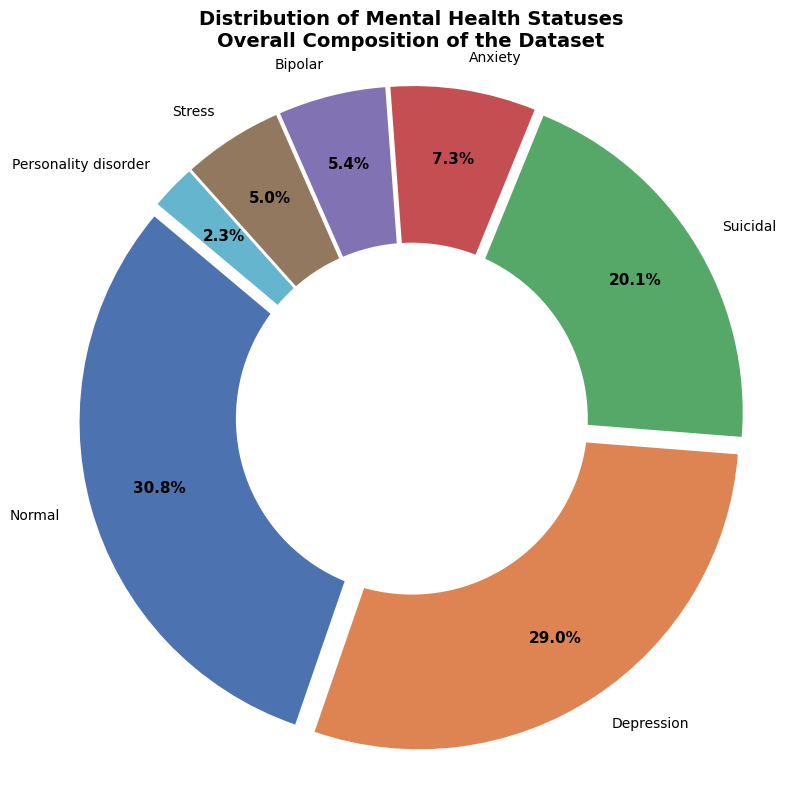

In [9]:
# Visualizing the distribution of mental health statuses

status_counts = df['status'].value_counts()

colors = [
    '#4C72B0',  # blue
    '#DD8452',  # orange
    '#55A868',  # green
    '#C44E52',  # red
    '#8172B3',  # purple
    '#937860',  # brown
    '#64B5CD'   # cyan
]

explode = [0.04] * len(status_counts)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.78,
    shadow=False
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.title(
    'Distribution of Mental Health Statuses\n'
    'Overall Composition of the Dataset',
    fontsize=14,
    weight='bold'
)

plt.axis('equal')
plt.tight_layout()
plt.show()

In [10]:
# Checking for missing values in the dataframe

df.isna().sum()

statement    362
status         0
dtype: int64

In [11]:
# Dropping rows with missing values and checking again for missing values

df.dropna(inplace = True)
df.isna().sum()

statement    0
status       0
dtype: int64

In [12]:
# Selecting a random statement for each mental health status

random_statements = df.groupby('status')['statement'].apply(lambda x: x.sample(n=1).iloc[0])

# Printing the results

for status, statement in random_statements.items():
    print(f"Status: {status}")
    print(f"Statement: {statement}\n")

Status: Anxiety
Statement: Possible Ear Infection? So my left ear is a bit red and itchy, it also feels like it’s burning and it’s tender to touch in certain places, especially just before the inside of the ear and behind the ear like the rounded bit on the outside.

I think it might be my earphones that have caused the problem so I’ve stopped using them for a couple days.

I’m not sure if this is something I should go to the doctor about or not. I know ear infections and stuff don’t really need treated but I wasn’t sure if I should just wait it out or go see a doctor about it. 

Status: Bipolar
Statement: I really just can't commit During a manic period I committed to a volunteer position that I didn't realize was actually a 2 year commitment and I have now (as of last week) committed to another year in this position because I can't say no.  We have a big event tomorrow and I just don't want to go.  I am one of 2 social media coordinators (and the better of the 2) so I'm supposed to b

In [13]:
# Analyzing the length of statements

df['num_of_characters'] = df['statement'].str.len()
df['num_of_sentences'] = df['statement'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Displaying descriptive statistics for the new columns

description = df[['num_of_characters', 'num_of_sentences']].describe()
description

,num_of_characters,num_of_sentences
count,52681.000000,52681.000000
mean,578.713863,6.280215
std,846.269078,10.688388
min,2.000000,1.000000
25%,80.000000,1.000000
50%,317.000000,3.000000
75%,752.000000,8.000000
max,32759.000000,1260.000000


In [14]:
# Displaying the entire data with new columns (num_of_characters, num_of_sentences)

df

,statement,status,num_of_characters,num_of_sentences
0,oh my gosh,Anxiety,10,1
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,2
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,2
3,I've shifted my focus to something else but I'...,Anxiety,61,1
4,"I'm restless and restless, it's been a month n...",Anxiety,72,2
...,...,...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,1766,16
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety,1012,12
53040,Is there any way to sleep better? I can't slee...,Anxiety,85,2
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety,401,6


In [15]:
# Splitting the dataset into training and testing sets

X = df["statement"]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Encoding the target labels

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [17]:
# Encoding the text data using TF-IDF Vectorization

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000) 

X_train = vectorizer.fit_transform(X_train) 
X_test = vectorizer.transform(X_test)

In [18]:
# Training a Logistic Regression model

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [19]:
# Making predictions on the test set

y_pred = log_reg.predict(X_test)

In [20]:
# Evaluating the model's performance

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.7778305020404289

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.79      0.80      0.80       768
             Bipolar       0.74      0.81      0.78       556
          Depression       0.81      0.63      0.71      3081
              Normal       0.89      0.92      0.91      3269
Personality disorder       0.54      0.73      0.63       215
              Stress       0.52      0.72      0.60       517
            Suicidal       0.69      0.77      0.73      2131

            accuracy                           0.78     10537
           macro avg       0.71      0.77      0.74     10537
        weighted avg       0.79      0.78      0.78     10537



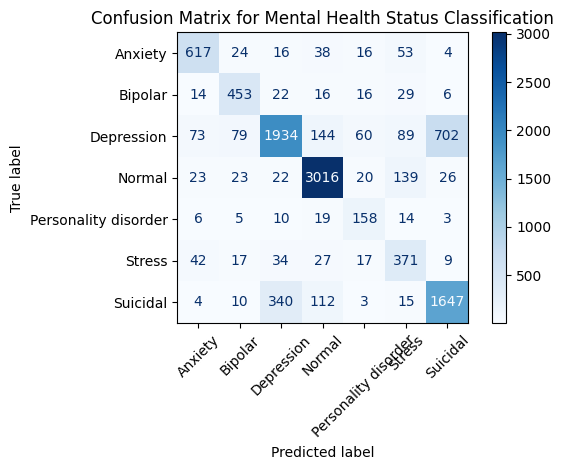

In [21]:
# Visualizing the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix for Mental Health Status Classification")
plt.tight_layout()
plt.show()